# Gera série temporal usando a função nativa do GEE chamada de `reducer`

- Fonte: https://www.youtube.com/watch?v=pKiE-Zxv44s
- Dados: Utilizeremos os dados de Temperatura da Superfície do Sensor MODIS - https://developers.google.com/earth-engine/datasets/catalog/MODIS_061_MOD11A2?hl=pt-br

# **1° Passo:** Preparando ambiente

In [ ]:
# importa bibliotecas
import ee, geemap

# inicializando
geemap.ee_initialize(project='ee-enrique')

# demais processos
import datetime
import matplotlib.pyplot as plt

# **PARTE 1):** Processamento

In [ ]:
# definindo a região de interesse: Baseado na lat/lon do local e um raio de 50 mil metros centrado nessa localidade, nesse caso Nova Deli-India
roi = ee.Geometry.Point([77.1025, 28.7041]).buffer(50_000)
roi

ee.Geometry({
  "functionInvocationValue": {
    "functionName": "Geometry.buffer",
    "arguments": {
      "distance": {
        "constantValue": 50000
      },
      "geometry": {
        "functionInvocationValue": {
          "functionName": "GeometryConstructors.Point",
          "arguments": {
            "coordinates": {
              "constantValue": [
                77.1025,
                28.7041
              ]
            }
          }
        }
      }
    }
  }
})

In [ ]:
# mostra mapa com a localização da ROI
Map = geemap.Map()
Map.addLayer(roi)
Map.centerObject(roi, 9)
Map

Map(center=[28.70415129235133, 77.10250162169409], controls=(WidgetControl(options=['position', 'transparent_b…

In [ ]:
# data inical e final
start_date = '2022-01-01'
end_date = '2022-12-31'

In [ ]:
# carrega os dados
modis_lst = ee.ImageCollection("MODIS/061/MOD11A2") \
              .filterDate(start_date, end_date) \
              .select('LST_Day_1km') \
              .filterBounds(roi) \
              .map(lambda image: image.multiply(0.02).subtract(273.15).copyProperties(image, ['system:time_start']))
modis_lst

In [ ]:
# quantidade de imagens da coleção
modis_lst.size()

In [ ]:
# função que extrae a série temporal
def reduce_region(image):
    serie_temporal = image.reduceRegion(reducer=ee.Reducer.mean(),
                                        geometry=roi,
                                        scale=1000,
                                        maxPixels=1e9)

    return ee.Feature(None, { 'LST': serie_temporal.get('LST_Day_1km'),
                              'date': image.date().format('YYYY-MM-dd') } )

In [ ]:
# dados com os filtros aplicados
features = modis_lst.map(reduce_region).filter(ee.Filter.notNull(['LST']))
features

In [ ]:
# extrai as informações de datas e valores
lst_values = features.getInfo()['features']
lst_values

In [ ]:
# extrai as datas
dates = [datetime.datetime.strptime(feature['properties']['date'], '%Y-%m-%d') for feature in lst_values]
dates

In [ ]:
# extrai os valores de temperatura
lst = [feature['properties']['LST'] for feature in lst_values]
lst

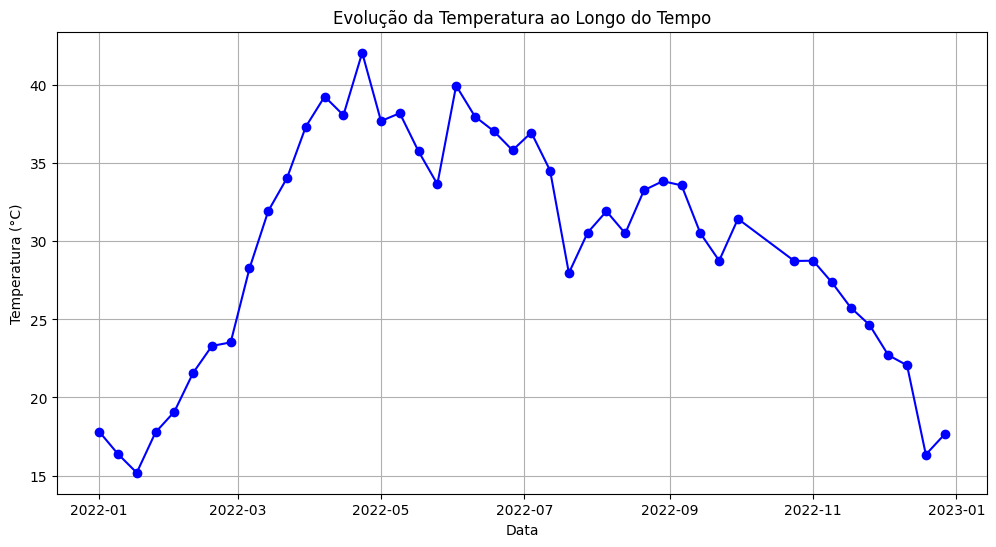

In [ ]:
# gráfico da série temporal
plt.figure(figsize=(12,6))
plt.plot(dates, lst, marker='o', linestyle='-', color='b')
plt.xlabel('Data')
plt.ylabel('Temperatura (°C)')
plt.title('Evolução da Temperatura ao Longo do Tempo')
plt.grid(True)
plt.show()

In [ ]:
# calcula a média na área
average_lst = modis_lst.mean().clip(roi)

In [ ]:
# parâmetros da visualização
vis = {'min': 27, 'max': 36, 'palette': ['blue', 'cyan', 'yellow', 'orange', 'red']}

In [ ]:
# plota mapa
Map = geemap.Map()
Map.addLayer(roi)
Map.centerObject(roi, 9)
Map.addLayer(average_lst, vis)
Map

Map(center=[28.70415129235133, 77.10250162169409], controls=(WidgetControl(options=['position', 'transparent_b…